In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the real velocity CSV file
real_velocity_df = pd.read_csv('real_velocity.csv')  # Replace with your real velocity CSV file

# Initialize a DataFrame to store accuracy results
accuracy_df = pd.DataFrame(columns=['Parameters', 'Accuracy'])

# Function to calculate normalized RMSE between real and generated velocities
def calculate_normalized_rmse(real, generated):
    rmse = np.sqrt(np.mean((real - generated)**2))
    target_range = np.max(real) - np.min(real)
    normalized_rmse = rmse / target_range
    return 1 - normalized_rmse  # To make it an accuracy-like metric

# List of generated velocity CSV files
generated_files = ['velocity generated/df_lk.csv', 'velocity generated/df_corners_1.csv', 'velocity generated/df_corners_2.csv',
                    'velocity generated/df_corners_3.csv', 'velocity generated/df_quality_1.csv', 'velocity generated/df_quality_2.csv']

# Loop through each generated velocity file
for generated_file in generated_files:
    # Load the generated velocity CSV file
    generated_df = pd.read_csv(generated_file)

    # Extract the column name for velocity ('v')
    velocity_column_name = [col for col in generated_df.columns if 'v' in col.lower()][0]

    # Merge real and generated DataFrames based on the common index (assuming the DataFrames have the same length)
    merged_df = pd.merge(real_velocity_df, generated_df, left_index=True, right_index=True)

    # Calculate accuracy for each row and average accuracy for the entire set
    merged_df['Accuracy'] = calculate_normalized_rmse(merged_df['velocity'], merged_df[velocity_column_name])

    # Calculate average accuracy for the entire set of parameters
    average_accuracy = merged_df['Accuracy'].mean()

    # Append the results to the accuracy DataFrame
    accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)

# Save the accuracy results to a new CSV file
accuracy_df.to_csv('accuracy_results.csv', index=False)

# Display the accuracy results
print(accuracy_df)


                            Parameters  Accuracy
0         velocity generated/df_lk.csv  0.759634
1  velocity generated/df_corners_1.csv  0.759634
2  velocity generated/df_corners_2.csv  0.759633
3  velocity generated/df_corners_3.csv  0.759630
4  velocity generated/df_quality_1.csv  0.759907
5  velocity generated/df_quality_2.csv  0.760134


C:\Users\DELL\AppData\Local\Temp\ipykernel_9284\2626883217.py:40: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_9284\2626883217.py:40: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_9284\2626883217.py:40: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_9284\2626883

In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the real velocity CSV file
real_velocity_df = pd.read_csv('real_velocity.csv')  # Replace with your real velocity CSV file

# Initialize a DataFrame to store accuracy results
accuracy_df = pd.DataFrame(columns=['Parameters', 'RMSE', 'MAE', 'MSE'])

# Function to calculate normalized RMSE between real and generated velocities
def calculate_normalized_rmse(real, generated):
    rmse = np.sqrt(np.mean((real - generated)**2))
    target_range = np.max(real) - np.min(real)
    normalized_rmse = rmse / target_range
    return 1 - normalized_rmse  # To make it an accuracy-like metric

# List of generated velocity CSV files
generated_files = ['velocity generated/df_lk.csv', 'velocity generated/df_corners_1.csv', 'velocity generated/df_corners_2.csv',
                    'velocity generated/df_corners_3.csv', 'velocity generated/df_quality_1.csv', 'velocity generated/df_quality_2.csv']

# Loop through each generated velocity file
for generated_file in generated_files:
    # Load the generated velocity CSV file
    generated_df = pd.read_csv(generated_file)

    # Extract the column name for velocity ('v')
    velocity_column_name = [col for col in generated_df.columns if 'v' in col.lower()][0]

    # Merge real and generated DataFrames based on the common index (assuming the DataFrames have the same length)
    merged_df = pd.merge(real_velocity_df, generated_df, left_index=True, right_index=True)

    # Calculate metrics for each row
    rmse = np.sqrt(mean_squared_error(merged_df['velocity'], merged_df[velocity_column_name]))
    mae = mean_absolute_error(merged_df['velocity'], merged_df[velocity_column_name])
    mse = mean_squared_error(merged_df['velocity'], merged_df[velocity_column_name])

    # Append the results to the accuracy DataFrame
    accuracy_df = accuracy_df.append({'Parameters': generated_file, 'RMSE': rmse, 'MAE': mae, 'MSE': mse}, ignore_index=True)

# Save the accuracy results to a new CSV file
# accuracy_df.to_csv('accuracy_results.csv', index=False)




C:\Users\DELL\AppData\Local\Temp\ipykernel_14100\3060069553.py:39: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'RMSE': rmse, 'MAE': mae, 'MSE': mse}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_14100\3060069553.py:39: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'RMSE': rmse, 'MAE': mae, 'MSE': mse}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_14100\3060069553.py:39: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'RMSE': rmse, 'MAE': mae, 'MSE': mse}, ignore_index=True)
C:\Users\DELL\AppData\Local\

In [2]:
# Display the accuracy results
accuracy_df

,Parameters,RMSE,MAE,MSE
0,velocity generated/df_lk.csv,2710.538304,1047.755115,7.347018e+06
1,velocity generated/df_corners_1.csv,2710.542401,1047.899212,7.347040e+06
2,velocity generated/df_corners_2.csv,2710.552053,1047.963415,7.347092e+06
3,velocity generated/df_corners_3.csv,2710.586550,1047.822495,7.347279e+06
4,velocity generated/df_quality_1.csv,2707.461341,1051.570334,7.330347e+06
5,velocity generated/df_quality_2.csv,2704.899928,1051.397594,7.316484e+06


# Default parameter

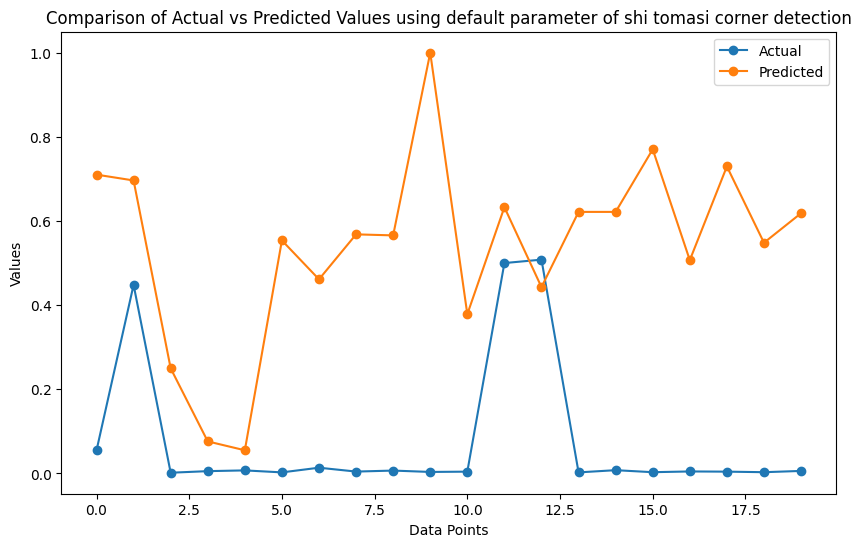

In [5]:
real_velocity_df = pd.read_csv('normalized_real_velocity.csv')  
df = pd.read_csv('Normalized_Predicted_velocity_shi_tomasi/df_lk.csv')  


first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df['v_lk'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values using default parameter of shi tomasi corner detection')

# Add legend
plt.legend()

# Show the plot
plt.show()


# Quality level parameter = 0.9

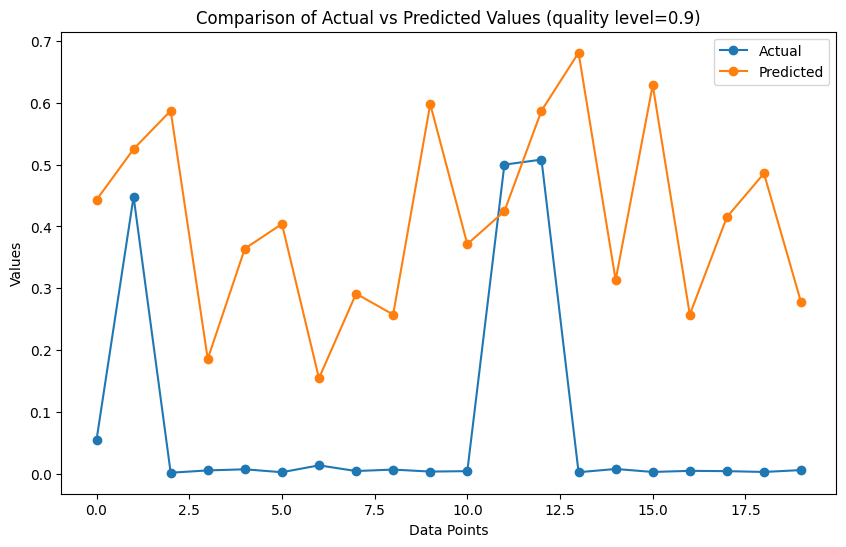

In [6]:
real_velocity_df = pd.read_csv('normalized_real_velocity.csv')  
df = pd.read_csv('Normalized_Predicted_velocity_shi_tomasi/df_quality_1.csv')  


first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df['v_quality_1'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values (quality level=0.9)')

# Add legend
plt.legend()

# Show the plot
plt.show()


# Quality level parameter = 0.8

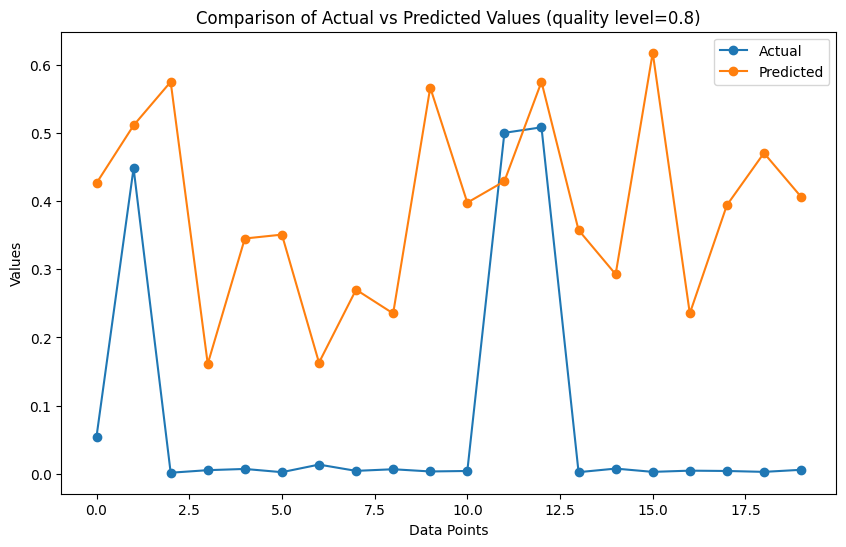

In [13]:
df = pd.read_csv('Normalized_Predicted_velocity_shi_tomasi/df_quality_2.csv')  


first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df['v_quality_2'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values (quality level=0.8)')

# Add legend
plt.legend()

# Show the plot
plt.show()


# Number of Corner = 500

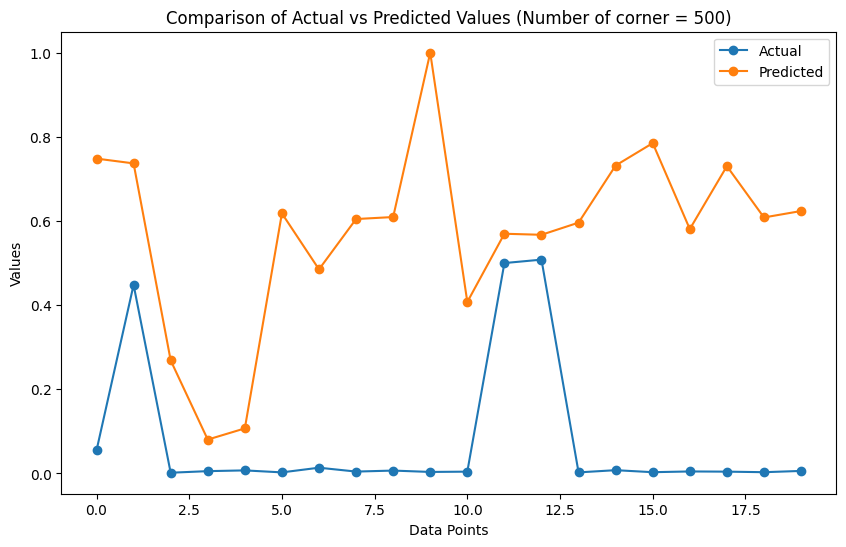

In [14]:
df = pd.read_csv('Normalized_Predicted_velocity_shi_tomasi/df_corners_1.csv')  


first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df['v_corners_1'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values (Number of corner = 500)')

# Add legend
plt.legend()

# Show the plot
plt.show()


# Number of Corner = 200

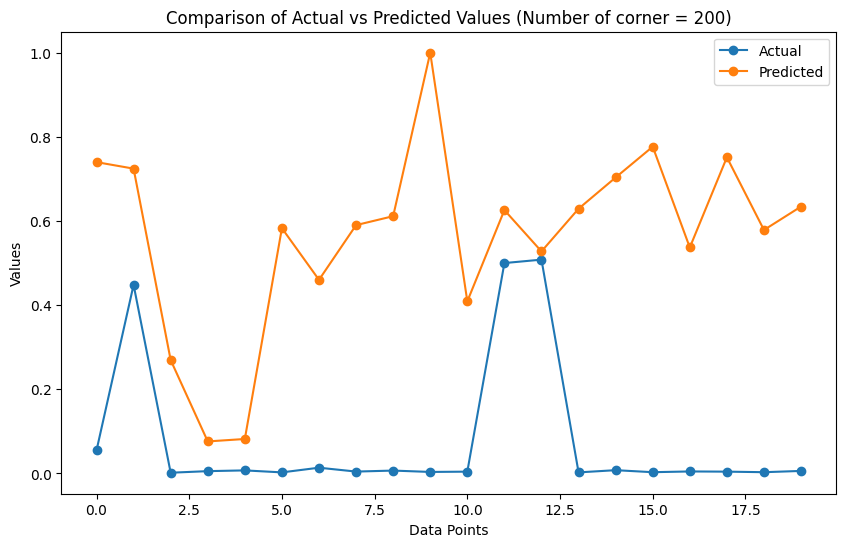

In [15]:
df = pd.read_csv('Normalized_Predicted_velocity_shi_tomasi/df_corners_2.csv')  


first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df['v_corners_2'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values (Number of corner = 200)')

# Add legend
plt.legend()

# Show the plot
plt.show()


# Number of Corner = 300

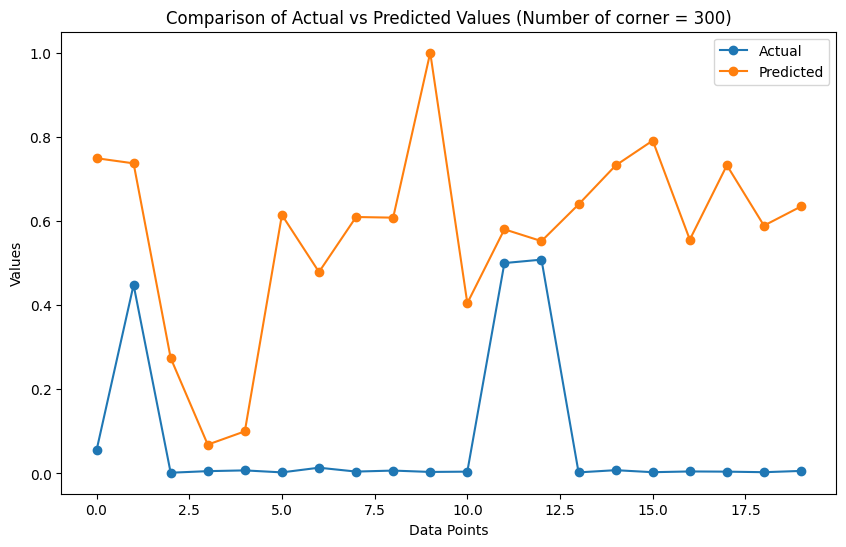

In [16]:
df = pd.read_csv('Normalized_Predicted_velocity_shi_tomasi/df_corners_3.csv')  


first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df['v_corners_3'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values (Number of corner = 300)')

# Add legend
plt.legend()

# Show the plot
plt.show()
